In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("./CSVs/data_science_job.csv")

In [6]:
df.shape

(19158, 13)

In [9]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [14]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [28]:
del_list=list()
for var in df.columns:
    if(df[var].isnull().mean()*100 <= 5.0 and df[var].isnull().mean()*100 > 0.0):
        del_list.append(var)

In [29]:
del_list

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [31]:
import matplotlib.pyplot as plt

In [34]:
len(df[del_list].dropna()) / len(df)

0.8968577095730244

In [38]:
new_df=df[del_list].dropna()

In [39]:
df.shape, new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

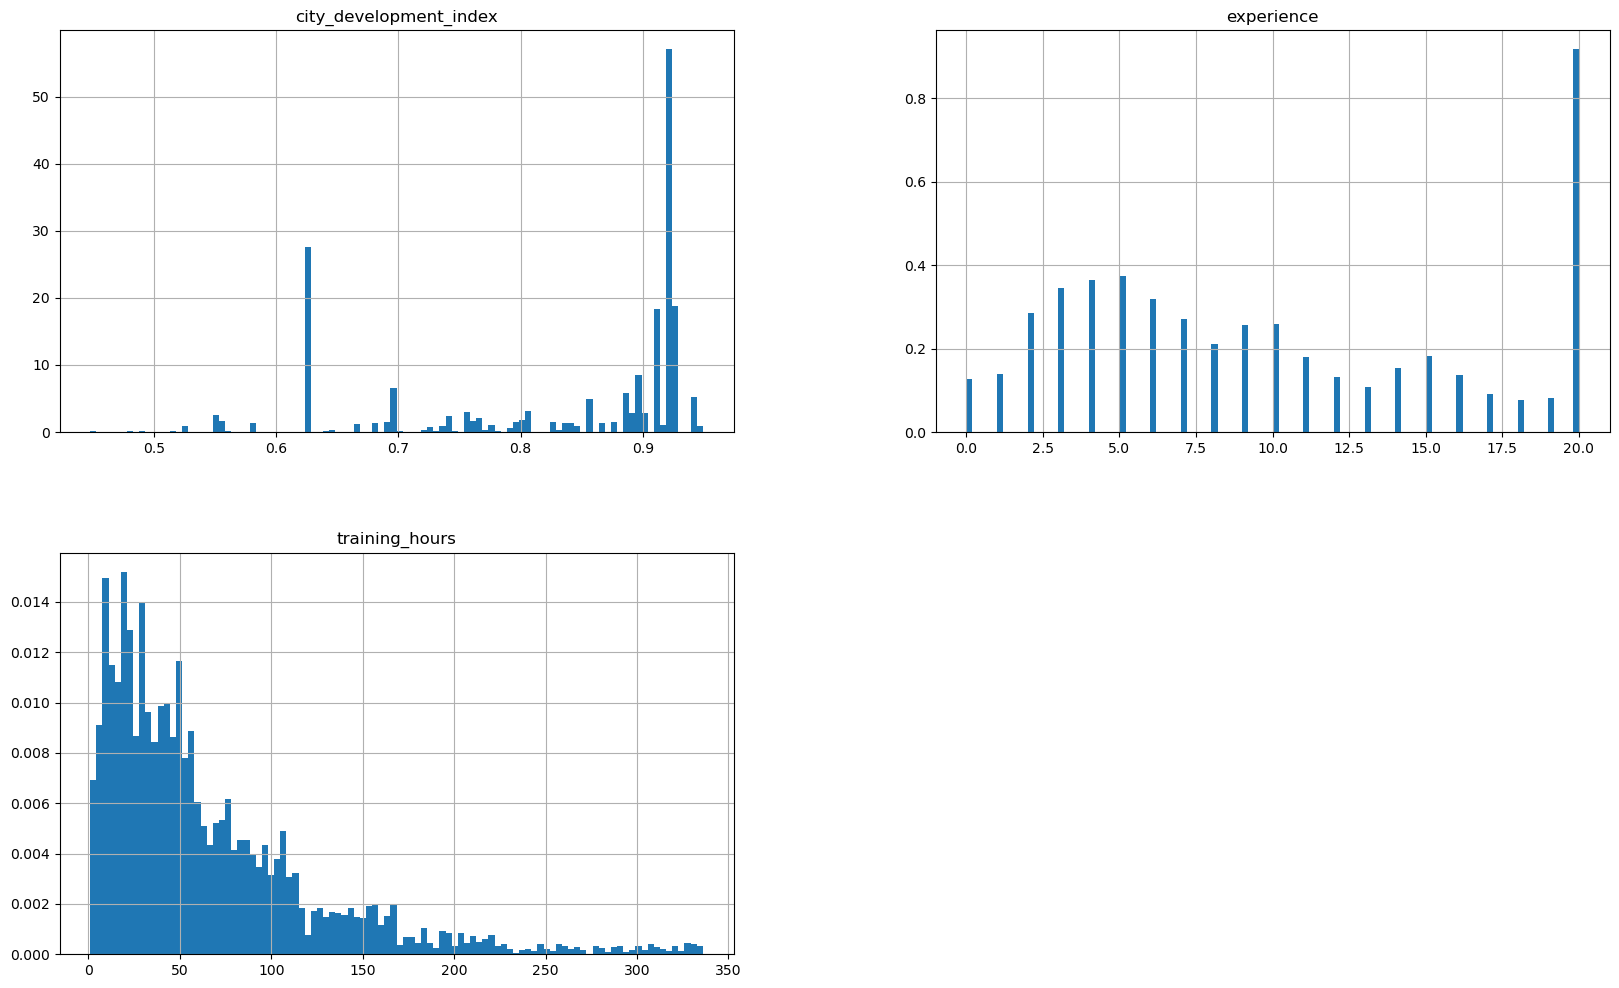

In [50]:
new_df.hist(bins=100,density=True,figsize=(20,12))

In [48]:
import matplotlib.pyplot as plt

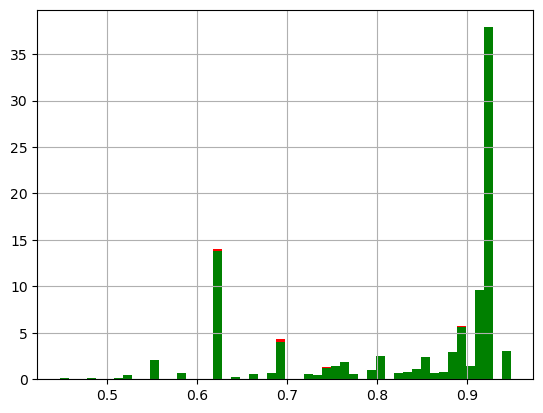

In [60]:
fig=plt.figure()
a_x=fig.add_subplot()

df['city_development_index'].hist(bins=50,color='red',density=True,ax=a_x)
new_df['city_development_index'].hist(bins=50,color='green',density=True,ax=a_x)
plt.show()

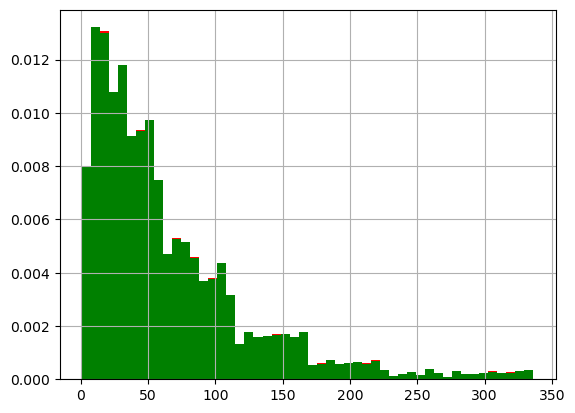

In [62]:
fig=plt.figure()
a_x=fig.add_subplot()

df['training_hours'].hist(bins=50,color='red',density=True,ax=a_x)
new_df['training_hours'].hist(bins=50,color='green',density=True,ax=a_x)
plt.show()

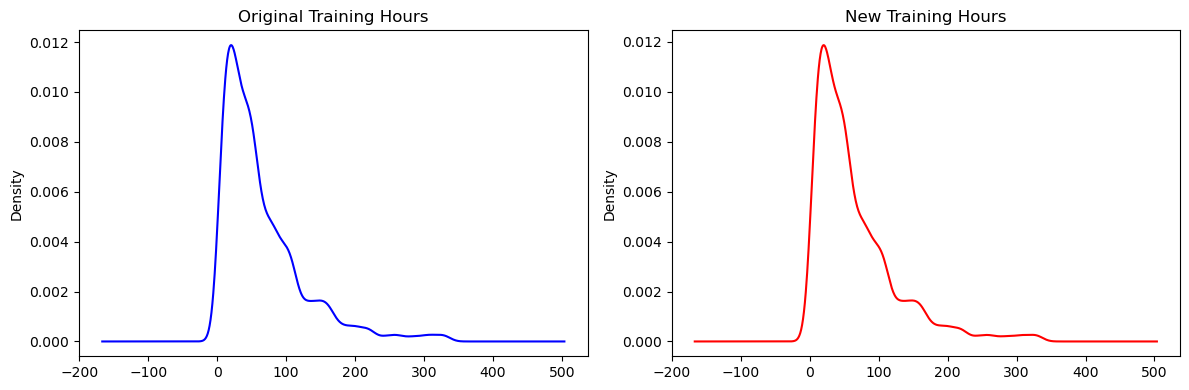

In [68]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


df['training_hours'].plot.density(color='blue', ax=ax1)
ax1.set_title('Original Training Hours')


new_df['training_hours'].plot.density(color='red', ax=ax2)
ax2.set_title('New Training Hours')

plt.tight_layout() 
plt.show()



In [78]:
temp=pd.concat([df.enrolled_university.value_counts()/len(df),new_df.enrolled_university.value_counts()/len(new_df)],axis=1)

In [79]:
temp.columns=['before','after']

In [80]:
temp

,before,after
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [81]:
temp=pd.concat([df.education_level.value_counts()/len(df),new_df.education_level.value_counts()/len(new_df)],axis=1)


In [82]:
temp

,count,count
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
